# Greffe de négatifs « intact » dans le modèle CarDD

Le modèle de la baseline (`01_baseline.ipynb`, macro-F1 0,815) n'a jamais vu de voiture intacte :
CarDD ne contient que des dégâts (fiche 0001), et le modèle prédit un dégât sur tout — aire ROC
**0,509** sur photos d'annonce (fiche 0002), soit un classement aléatoire.

**Le constat qui rend la greffe possible** : l'architecture sait déjà dire « rien ». En
multi-étiquette, « intact » = les six sorties sous le seuil, c'est-à-dire la cible
`[0,0,0,0,0,0]`. Il n'y a pas de 7e classe à ajouter — il manquait uniquement des **exemples**.

**La source de négatifs** : les photos leboncoin déclarées intactes (fiables à ~98 %, fiche 0003),
découpées en gros plans de carrosserie (détourage puis tuiles dans la boîte véhicule) pour
ressembler au cadrage CarDD. Un dataset externe (Stanford Cars, etc.) aurait un style trop
différent : le réseau apprendrait à reconnaître la **source** de la photo, pas le dégât.

## Garde-fous

1. **Anti-fuite** : les tuiles proviennent d'annonces **hors** du lot d'annotation — les 471
   verdicts restent un jeu d'évaluation vierge. Vérifié par assertion ci-dessous.
2. **Biais de source inversé, testé par construction** : après greffe, abîmés = style CarDD,
   intacts = style leboncoin. Si le réseau apprend le style au lieu du contenu, il répondra
   « intact » aux 105 photos abîmées leboncoin de l'évaluation, et l'aire ROC restera ~0,5 :
   l'évaluation détecte ce mode d'échec.
3. **Protocole inchangé** (fiche 0001) : 10 époques à budget fixe, meilleure époque sur
   validation, `test2017` fermé.

In [1]:
import sys
sys.path.insert(0, "../../src")

from pathlib import Path
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.metrics import roc_auc_score

from cardd import CarDDMultiLabel, TuilesIntactes, CarDDAvecNegatifs, CLASSES
from device import get_device
import train_cardd as tc

COCO = "../../data/cardd/raw/CarDD_release/CarDD_COCO"
NEG = Path("../../data/cardd/negatifs")
ANNOT = Path("../../data/leboncoin-private/annot")
GRAINE, TAILLE, LOTS, EPOQUES = 0, 224, 32, 10

tc.set_seed(GRAINE)
device = get_device()
print("device :", device)

man_neg = pd.read_csv(NEG / "manifeste_negatifs.csv", dtype={"ad_id": str})
man_annot = pd.read_csv(ANNOT / "manifeste.csv", dtype={"ad_id": str})
communs = set(man_neg.ad_id) & set(man_annot.ad_id)
assert not communs, f"FUITE : {len(communs)} annonces des tuiles figurent dans le lot d'annotation"
print(f"anti-fuite : OK — {man_neg.ad_id.nunique()} annonces de tuiles, "
      f"aucune commune avec les {man_annot.ad_id.nunique()} annotées")
print(man_neg.split.value_counts().to_string())

device : mps
anti-fuite : OK — 697 annonces de tuiles, aucune commune avec les 800 annotées
split
train    1671
val       420


## 1. Les tuiles — à quoi ressemblent les négatifs

Contrôle visuel obligatoire : si les tuiles contiennent du bitume, du ciel ou un intérieur, le
modèle apprendra « fond = intact » au lieu de « carrosserie saine = intact ».

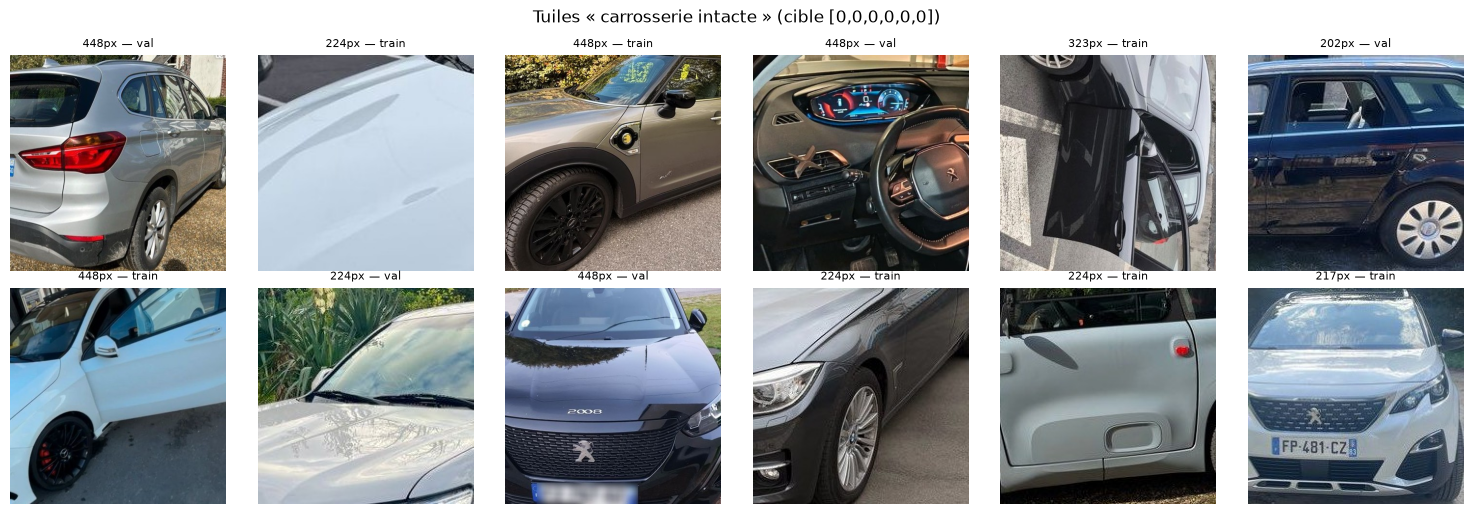

In [2]:
rng = np.random.default_rng(GRAINE)
choix = rng.choice(len(man_neg), 12, replace=False)
fig, axes = plt.subplots(2, 6, figsize=(15, 5.2))
for ax, i in zip(axes.ravel(), choix):
    ligne = man_neg.iloc[i]
    ax.imshow(Image.open(NEG / ligne.fichier))
    ax.set_title(f"{ligne.cote}px — {ligne.split}", fontsize=8)
    ax.axis("off")
plt.suptitle("Tuiles « carrosserie intacte » (cible [0,0,0,0,0,0])")
plt.tight_layout(); plt.show()

## 2. Ré-entraînement — CarDD + tuiles, protocole de la baseline

`pos_weight` est recalculé sur l'ensemble combiné : les tuiles ajoutent des négatifs à **chaque**
classe, donc les poids montent — les classes rares restent compensées face au volume ajouté.

In [3]:
tf = tc.build_transforms(TAILLE)
cardd_train = CarDDMultiLabel(COCO, "train", tf)
cardd_val = CarDDMultiLabel(COCO, "val", tf)
tuiles_train = TuilesIntactes(NEG / "train", tf)
tuiles_val = TuilesIntactes(NEG / "val", tf)

train_ds = CarDDAvecNegatifs(cardd_train, tuiles_train)
val_ds = CarDDAvecNegatifs(cardd_val, tuiles_val)
print(f"train : {len(cardd_train)} CarDD + {len(tuiles_train)} tuiles = {len(train_ds)}")
print(f"val   : {len(cardd_val)} CarDD + {len(tuiles_val)} tuiles = {len(val_ds)}")

display(pd.DataFrame({
    "pos_weight CarDD seul": cardd_train.pos_weight().numpy().round(2),
    "pos_weight avec tuiles": train_ds.pos_weight().numpy().round(2),
}, index=CLASSES))

train : 2816 CarDD + 1671 tuiles = 4487
val   : 810 CarDD + 420 tuiles = 1230


,pos_weight CarDD seul,pos_weight avec tuiles
dent,1.27,2.61
scratch,0.87,1.98
crack,5.49,9.34
glass shatter,5.00,8.57
lamp broken,4.76,8.18
tire flat,11.86,19.49


In [4]:
tc.set_seed(GRAINE)
modele = tc.build_model("resnet18", gele=False)
res = tc.train(modele, train_ds, val_ds, device,
               epochs=EPOQUES, lr=1e-4, batch_size=LOTS, num_workers=0, seed=GRAINE)
print(f"\nmeilleure époque : {res['meilleur_epoch']} | macro-F1 val (combinée) : "
      f"{res['meilleur_macro_f1']:.4f}")
modele.load_state_dict(res["best_state_dict"])
modele = modele.to(device).eval()

époque  1/10 | perte 0.5307 | macro-F1 val 0.6899 | 57.7 s


époque  2/10 | perte 0.2547 | macro-F1 val 0.7881 | 54.7 s


époque  3/10 | perte 0.1420 | macro-F1 val 0.7965 | 55.4 s


époque  4/10 | perte 0.0768 | macro-F1 val 0.7990 | 55.2 s


époque  5/10 | perte 0.0637 | macro-F1 val 0.8010 | 54.3 s


époque  6/10 | perte 0.0390 | macro-F1 val 0.8018 | 56.8 s


époque  7/10 | perte 0.0349 | macro-F1 val 0.7733 | 55.0 s


époque  8/10 | perte 0.0356 | macro-F1 val 0.8138 | 55.1 s


époque  9/10 | perte 0.0268 | macro-F1 val 0.8088 | 54.9 s


époque 10/10 | perte 0.0211 | macro-F1 val 0.8091 | 57.6 s

meilleure époque : 8 | macro-F1 val (combinée) : 0.8138


## 3. Verdict, volet 1 — le typage tient-il ?

macro-F1 sur `val2017` **seul** (sans les tuiles), pour comparer à la baseline à périmètre
identique. Dégradation tolérée : < 0,03.

In [5]:
baseline, _ = tc.charger_checkpoint("../../models/cardd_baseline.pt", device)
val_loader = tc.make_loader(cardd_val, LOTS, num_workers=0)

p_base, cibles = tc.predict_probas(baseline, val_loader, device)
p_greffe, _ = tc.predict_probas(modele, val_loader, device)
s_base, s_greffe = tc.evaluate(p_base, cibles), tc.evaluate(p_greffe, cibles)

comp = pd.DataFrame({"baseline (0,815)": s_base["F1"], "greffé": s_greffe["F1"]})
comp["écart"] = (comp["greffé"] - comp["baseline (0,815)"]).round(4)
display(comp)
ecart_macro = float(comp.loc["macro", "écart"])
print(f"écart macro-F1 : {ecart_macro:+.4f} " +
      ("— typage préservé" if ecart_macro > -0.03 else "— DÉGRADATION au-delà du seuil toléré"))

,"baseline (0,815)",greffé,écart
dent,0.7791,0.7842,0.0051
scratch,0.8177,0.8214,0.0037
crack,0.6292,0.6504,0.0212
glass shatter,0.9699,0.9665,-0.0034
lamp broken,0.7633,0.7961,0.0328
tire flat,0.9310,0.8871,-0.0439
macro,0.8150,0.8176,0.0026
micro,0.8021,0.8103,0.0082


écart macro-F1 : +0.0026 — typage préservé


## 4. Verdict, volet 2 — le modèle sait-il dire « rien » ?

Taux de fausse alerte (au moins une sortie > 0,5) sur les tuiles intactes de **validation** —
des annonces jamais vues à l'entraînement. Attendu : proche de 100 % pour la baseline (elle n'a
jamais vu d'intact), bas pour le modèle greffé.

In [6]:
tuiles_loader = tc.make_loader(tuiles_val, LOTS, num_workers=0)
fa = {}
for nom, m in (("baseline", baseline), ("greffé", modele)):
    p, _ = tc.predict_probas(m, tuiles_loader, device)
    fa[nom] = {"fausse alerte (≥1 classe > 0,5)": f"{(p.max(axis=1) > 0.5).mean()*100:.1f} %",
               "proba max moyenne": round(float(p.max(axis=1).mean()), 3)}
display(pd.DataFrame(fa).T)

,"fausse alerte (≥1 classe > 0,5)",proba max moyenne
baseline,80.2 %,0.743
greffé,2.9 %,0.067


## 5. Verdict, volet 3 — le juge de paix : les 471 photos annotées

Aire ROC contre les verdicts humains, en deux modes d'inférence :

- **pleine photo** : redimensionnement direct à 224 px — l'usage naïf ;
- **tuiles sur détourage** (`tile_max_probs`) : le mode qui saturait avec la baseline (variante C
  du sondage), et qui devrait devenir utilisable si la greffe a appris « rien ».

Références : **0,509** (baseline pleine photo, fiche 0002) et **0,855** (binaire dédié 384 px
détouré, fiche 0004).

In [7]:
from localize import tile_max_probs

verdicts = man_annot.assign(fichier=man_annot.id.astype(str).str.zfill(4) + ".jpg") \
    .merge(pd.read_csv(ANNOT / "verdicts.csv"), on="fichier")
verdicts = verdicts[verdicts.verdict.isin(["intact", "abime"])].reset_index(drop=True)
y = (verdicts.verdict == "abime").astype(int).values
print(f"{len(verdicts)} photos ({y.sum()} abîmées)")

_tf224 = tc.build_transforms(TAILLE)

@torch.no_grad()
def probas_pleine_photo(m, dossier):
    out = []
    for f in verdicts.fichier:
        x = _tf224(Image.open(dossier / f).convert("RGB")).unsqueeze(0).to(device)
        out.append(torch.sigmoid(m(x))[0].cpu().numpy())
    return np.array(out)

def probas_tuiles(m, dossier):
    out = []
    for f in verdicts.fichier:
        probs, _ = tile_max_probs(m, CLASSES, device, Image.open(dossier / f).convert("RGB"))
        out.append([probs[c] for c in CLASSES])
    return np.array(out)

lignes = []
for nom, m in (("baseline", baseline), ("greffé", modele)):
    pf = probas_pleine_photo(m, ANNOT / "img")
    pt = probas_tuiles(m, ANNOT / "img_crop")
    lignes.append({"modèle": nom,
                   "ROC pleine photo": round(roc_auc_score(y, pf.max(axis=1)), 3),
                   "ROC tuiles/détourage": round(roc_auc_score(y, pt.max(axis=1)), 3)})
juge = pd.DataFrame(lignes)
juge.loc[len(juge)] = {"modèle": "binaire dédié 384 px détouré (réf. 0004)",
                       "ROC pleine photo": None, "ROC tuiles/détourage": 0.855}
display(juge)

471 photos (105 abîmées)


,modèle,ROC pleine photo,ROC tuiles/détourage
0,baseline,0.509,0.496
1,greffé,0.64,0.706
2,binaire dédié 384 px détouré (réf. 0004),None,0.855


## 6. Checkpoint

In [8]:
config = {"arch": "resnet18", "taille": TAILLE, "lots": LOTS, "epoques": EPOQUES, "lr": 1e-4,
          "graine": GRAINE, "negatifs": len(tuiles_train), "meilleur_epoch": res["meilleur_epoch"],
          "macro_f1_val_combinee": res["meilleur_macro_f1"]}
chemin = tc.sauver_checkpoint("../../models/cardd_greffe.pt", res["best_state_dict"], config)
m2, meta = tc.charger_checkpoint(chemin, device)
p2, _ = tc.predict_probas(m2, tuiles_loader, device)
p1, _ = tc.predict_probas(modele, tuiles_loader, device)
print("écrit :", chemin, f"| rechargement identique : {np.abs(p2-p1).max():.2e}")

écrit : ../../models/cardd_greffe.pt | rechargement identique : 0.00e+00


## 7. Conclusion — la greffe fonctionne, et elle complète le binaire sans le remplacer

| volet | baseline | greffé | verdict |
|---|---|---|---|
| typage (macro-F1, `val2017` seul) | 0,815 | **0,818** | préservé (+0,003) |
| fausse alerte sur tuiles intactes jamais vues | **80,2 %** | **2,9 %** | « rien » appris |
| aire ROC 471 verdicts, pleine photo | 0,509 | 0,640 | sorti du hasard |
| aire ROC 471 verdicts, tuiles/détourage | 0,496 | **0,706** | utilisable, sous le binaire |
| binaire dédié 384 px détouré (réf. 0004) | — | — | **0,855** |

**Ce que la greffe a réglé.** Le modèle sait maintenant dire « rien » : la fausse alerte sur des
tuiles de carrosserie intacte — des annonces jamais vues — passe de 80,2 % à 2,9 %, et la
probabilité maximale moyenne de 0,743 à 0,067. Le typage n'a rien perdu (macro-F1 +0,003 ;
`tire flat` −0,044, le plus gros écart, reste dans le bruit d'une classe à 59 exemples de
validation). Ajouter ~1 700 tuiles à cible `[0,0,0,0,0,0]` a suffi — aucune modification
d'architecture, conformément au constat de départ.

**Ce que la greffe n'a pas réglé.** Sur les 471 photos d'annonce, le modèle greffé (0,706 en
tuiles) reste nettement sous le binaire dédié (0,855). Rien d'étonnant : le binaire est entraîné
exactement sur le domaine et la tâche de l'évaluation, quand la greffe apprend une tâche plus
riche avec des positifs d'un autre style (gros plans CarDD). Le biais de source inversé documenté
en tête de carnet plafonne probablement ce chiffre — les positifs n'existent qu'en style CarDD.

**Architecture qui en résulte** (à confirmer à l'usage) :

1. **étage 1 — binaire domaine annonce** (fiche 0004) : la photo est-elle abîmée ? 0,855 ;
2. **étage 2 — modèle greffé** sur le détourage ou les tuiles des photos jugées abîmées : quel
   type de dégât, et où (la tuile déclenchante localise). La greffe rend cet étage **fiable sur
   les zones saines** : avant, il inventait un dégât sur chaque tuile intacte (80 % de fausses
   alertes), ce qui rendait toute localisation par tuiles inutilisable — c'était l'échec de la
   variante C du sondage. À 2,9 %, la carte de tuiles redevient une carte de dégâts.

**Limites.**
- Négatifs issus d'étiquettes déclarées (~98 % fiables) : quelques dégâts discrets peuvent se
  glisser dans les tuiles « intactes ».
- Positifs uniquement en style CarDD : le 0,706 mesure autant le décalage de style que la
  capacité de détection. S'améliorerait avec des gros plans de dégâts leboncoin annotés — non
  disponible aujourd'hui sans campagne d'annotation localisée.
- Les 471 verdicts : un seul annotateur, un seul segment, juillet 2026.

**Gate.** Fiche 0005 à écrire après lecture : greffe **adoptée** comme étage de typage/localisation,
binaire dédié conservé comme étage de détection.